ERROR 1: PROJ: proj_create_from_database: Open of /home/k16v981/.conda/envs/my_env/share/proj failed



Found 900 ERA5-Land monthly files

Soil moisture variables:
  swvl1: ('time', 'latitude', 'longitude')
  swvl2: ('time', 'latitude', 'longitude')

Event counts:
      el_nino: 101 dates
      la_nina: 137 dates
 enso_neutral: 1700 dates
         piod: 26 dates
         niod: 39 dates
  iod_neutral: 1873 dates

Loading only event-date ERA5-Land data into RAM...
Loaded event data: time=1938, lat=340, lon=360

Event-month blocks:
      el_nino: 21 months
      la_nina: 10 months
 enso_neutral: 216 months
         piod: 6 months
         niod: 7 months
  iod_neutral: 234 months

el_nino: 21 phase months vs 216 neutral months


/tmp/ipykernel_1702180/687681214.py:644: RuntimeWarning: Mean of empty slice
  pmean = np.nanmean(
/tmp/ipykernel_1702180/687681214.py:649: RuntimeWarning: Mean of empty slice
  nmean = np.nanmean(
/tmp/ipykernel_1702180/687681214.py:716: RuntimeWarning: Mean of empty slice
  np.nanmean(
/tmp/ipykernel_1702180/687681214.py:721: RuntimeWarning: Mean of empty slice
  np.nanmean(


  100/1000
  200/1000
  300/1000
  400/1000
  500/1000
  600/1000
  700/1000
  800/1000
  900/1000
  1000/1000


/home/k16v981/.conda/envs/my_env/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,



la_nina: 10 phase months vs 216 neutral months
  100/1000
  200/1000
  300/1000
  400/1000
  500/1000
  600/1000
  700/1000
  800/1000
  900/1000
  1000/1000

piod: 6 phase months vs 234 neutral months
  100/1000
  200/1000
  300/1000
  400/1000
  500/1000
  600/1000
  700/1000
  800/1000
  900/1000
  1000/1000

niod: 7 phase months vs 234 neutral months
  100/1000
  200/1000
  300/1000
  400/1000
  500/1000
  600/1000
  700/1000
  800/1000
  900/1000
  1000/1000

Saved plotting products:
../figures/soil_moisture_composites/soil_moisture_phase_vs_neutral_bootstrap_products.nc


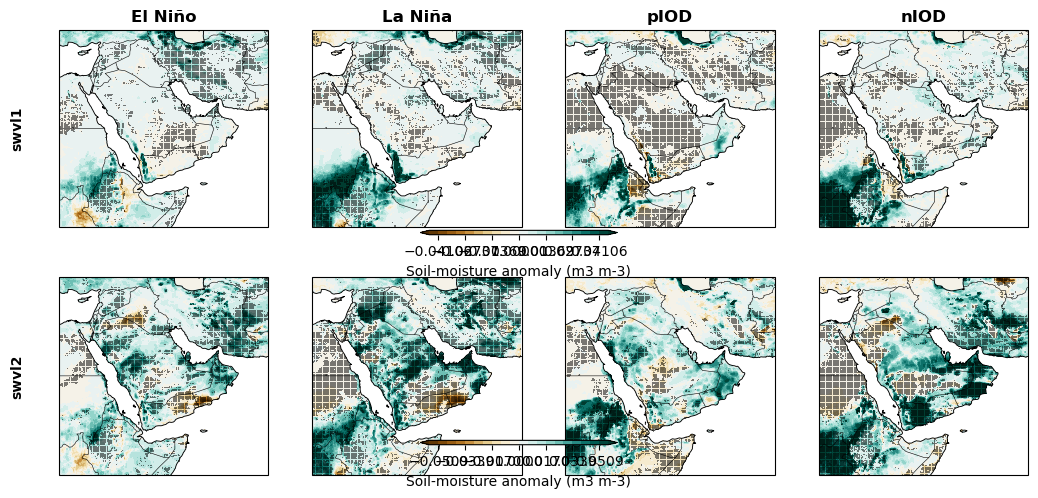


Saved PNG: ../figures/soil_moisture_composites/soil_moisture_phase_vs_neutral_bootstrap.png
Saved PDF: ../figures/soil_moisture_composites/soil_moisture_phase_vs_neutral_bootstrap_manuscript.pdf


In [1]:
# ============================================================
# ERA5-LAND SOIL MOISTURE:
# PHASE - NEUTRAL COMPOSITES + MONTH-BLOCK BOOTSTRAP
# ============================================================

import os
import glob
import warnings
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker

import cartopy.crs as ccrs
import cartopy.feature as cfeature


# ============================================================
# SETTINGS
# ============================================================

SOIL_GLOB = (
    "../data/land/soil_moisture/"
    "era5_land_soil_moisture_*.nc"
)

EVENT_CSV = (
    "../data/wbt_sst_city_runs/"
    "city_daily_wbt_JJAS_with_lagged_phases.csv"
)

OUT_DIR = Path("../figures/soil_moisture_composites")
OUT_DIR.mkdir(parents=True, exist_ok=True)

PRODUCTS_PATH = (
    OUT_DIR /
    "soil_moisture_phase_vs_neutral_bootstrap_products.nc"
)

PNG_PATH = (
    OUT_DIR /
    "soil_moisture_phase_vs_neutral_bootstrap.png"
)

PDF_PATH = (
    OUT_DIR /
    "soil_moisture_phase_vs_neutral_bootstrap_manuscript.pdf"
)


# HHE / phase settings
DAY_MODE = "p95"

MONTHS = [6, 7, 8, 9]

DATE_COL = "time"
CITY_COL = "city"
WBT_COL = "wbt_daily_peak"

ENSO_LAG = 2
IOD_LAG = 1

ENSO_POS_THRESH = 1.0
ENSO_NEG_THRESH = -1.0

IOD_POS_THRESH = 1.0
IOD_NEG_THRESH = -1.0


# Bootstrap
N_BOOT = 1000
N_WORKERS = 32
BOOT_SEED = 58

CI_LOW = 2.5
CI_HIGH = 97.5


# Map
LON_MIN, LON_MAX = 29, 65
LAT_MIN, LAT_MAX = 5, 39

ROBUST_PCT = 98

STIPPLE_SIZE = 1.3
STIPPLE_ALPHA = 0.60
STIPPLE_STRIDE = 2


COLUMN_KEYS = [
    "el_nino",
    "la_nina",
    "piod",
    "niod",
]

COLUMN_TITLES = [
    "El Niño",
    "La Niña",
    "pIOD",
    "nIOD",
]


# ============================================================
# PHASE HELPERS
# ============================================================

def classify_enso(x):
    if pd.isna(x):
        return np.nan
    if x >= ENSO_POS_THRESH:
        return "El Niño"
    if x <= ENSO_NEG_THRESH:
        return "La Niña"
    return "Neutral"


def classify_iod(x):
    if pd.isna(x):
        return np.nan
    if x >= IOD_POS_THRESH:
        return "pIOD"
    if x <= IOD_NEG_THRESH:
        return "nIOD"
    return "Neutral"


def load_event_phase_dates():

    raw = pd.read_csv(EVENT_CSV)

    raw[DATE_COL] = pd.to_datetime(
        raw[DATE_COL]
    )

    raw["month_start"] = (
        raw[DATE_COL]
        .dt.to_period("M")
        .dt.to_timestamp()
    )

    # -----------------------------------------------
    # Monthly teleconnection table before filtering
    # -----------------------------------------------

    monthly = (
        raw[raw["lag"] == 0][
            [
                "month_start",
                "RONI_lag",
                "DMI_lag",
            ]
        ]
        .drop_duplicates("month_start")
        .sort_values("month_start")
        .reset_index(drop=True)
    )

    monthly["enso_now"] = (
        monthly["RONI_lag"]
        .apply(classify_enso)
    )

    monthly["iod_now"] = (
        monthly["DMI_lag"]
        .apply(classify_iod)
    )


    # -----------------------------------------------
    # Shift source phases forward to response month
    # -----------------------------------------------

    enso_shift = monthly[
        ["month_start", "enso_now"]
    ].copy()

    enso_shift["month_start"] += (
        pd.DateOffset(months=ENSO_LAG)
    )

    enso_shift = enso_shift.rename(
        columns={
            "enso_now":
            "enso_shifted"
        }
    )


    iod_shift = monthly[
        ["month_start", "iod_now"]
    ].copy()

    iod_shift["month_start"] += (
        pd.DateOffset(months=IOD_LAG)
    )

    iod_shift = iod_shift.rename(
        columns={
            "iod_now":
            "iod_shifted"
        }
    )


    # -----------------------------------------------
    # Attach phases
    # -----------------------------------------------

    df = raw.merge(
        monthly[
            [
                "month_start",
                "enso_now",
                "iod_now",
            ]
        ],
        on="month_start",
        how="left",
    )

    df = df.merge(
        enso_shift,
        on="month_start",
        how="left",
    )

    df = df.merge(
        iod_shift,
        on="month_start",
        how="left",
    )


    df["month_num"] = (
        df[DATE_COL].dt.month
    )


    # Same fallback behavior as mechanism composites
    df["enso_final"] = df["enso_shifted"]

    mask = (
        df["enso_final"].isna()
        & df["month_num"].isin([6, 7])
    )

    df.loc[
        mask,
        "enso_final"
    ] = df.loc[
        mask,
        "enso_now"
    ]


    df["iod_final"] = df["iod_shifted"]

    mask = (
        df["iod_final"].isna()
        & df["month_num"].isin([6])
    )

    df.loc[
        mask,
        "iod_final"
    ] = df.loc[
        mask,
        "iod_now"
    ]


    # JJAS only
    df = df[
        df["month_num"].isin(MONTHS)
    ].copy()


    # -----------------------------------------------
    # Select p95 HHE days
    # -----------------------------------------------

    if DAY_MODE == "p95":

        df["threshold"] = (
            df.groupby(CITY_COL)[WBT_COL]
            .transform(
                lambda x:
                x.quantile(0.95)
            )
        )

        df = df[
            df[WBT_COL]
            >= df["threshold"]
        ].copy()


    # -----------------------------------------------
    # Unique event dates
    # -----------------------------------------------

    specs = [
        (
            "el_nino",
            "enso_final",
            "El Niño",
        ),
        (
            "la_nina",
            "enso_final",
            "La Niña",
        ),
        (
            "enso_neutral",
            "enso_final",
            "Neutral",
        ),
        (
            "piod",
            "iod_final",
            "pIOD",
        ),
        (
            "niod",
            "iod_final",
            "nIOD",
        ),
        (
            "iod_neutral",
            "iod_final",
            "Neutral",
        ),
    ]


    phase_dates = {}

    for key, col, label in specs:

        sub = df[
            df[col] == label
        ]

        phase_dates[key] = (
            pd.DatetimeIndex(
                sorted(
                    sub[DATE_COL]
                    .dt.normalize()
                    .unique()
                )
            )
        )


    print("\nEvent counts:")

    for key, dates in phase_dates.items():
        print(
            f"{key:>13s}: "
            f"{len(dates)} dates"
        )


    return phase_dates


# ============================================================
# OPEN SOIL MOISTURE
# ============================================================

files = sorted(
    glob.glob(SOIL_GLOB)
)

if not files:
    raise FileNotFoundError(
        f"No files matched:\n{SOIL_GLOB}"
    )


print(
    f"\nFound {len(files)} "
    "ERA5-Land monthly files"
)


ds = xr.open_mfdataset(
    files,
    combine="by_coords",
    engine="h5netcdf",
    parallel=False,
)


# Standardize time coordinate
if "valid_time" in ds.coords:
    ds = ds.rename(
        {"valid_time": "time"}
    )


# Sort spatial dimensions explicitly
if (
    ds.latitude[0]
    > ds.latitude[-1]
):
    ds = ds.sortby("latitude")

if (
    ds.longitude[0]
    > ds.longitude[-1]
):
    ds = ds.sortby("longitude")


ds = ds.sel(
    latitude=slice(
        LAT_MIN,
        LAT_MAX
    ),
    longitude=slice(
        LON_MIN,
        LON_MAX
    ),
)


if (
    ds.sizes["latitude"] == 0
    or ds.sizes["longitude"] == 0
):
    raise RuntimeError(
        "Empty AP spatial subset"
    )


# Detect soil-moisture variables
soil_vars = list(
    ds.data_vars
)

print(
    "\nSoil moisture variables:"
)

for v in soil_vars:
    print(
        f"  {v}: "
        f"{ds[v].dims}"
    )


# ============================================================
# EVENT DATES / SUBSET DATA BEFORE LOADING
# ============================================================

phase_dates = (
    load_event_phase_dates()
)


all_dates = pd.DatetimeIndex(
    sorted(
        set().union(
            *[
                set(d)
                for d in
                phase_dates.values()
            ]
        )
    )
)


soil_dates = (
    pd.DatetimeIndex(
        pd.to_datetime(
            ds["time"].values
        )
    )
    .normalize()
)


keep = np.isin(
    soil_dates.values,
    all_dates.values
)


print(
    "\nLoading only event-date "
    "ERA5-Land data into RAM..."
)


ds_event = (
    ds[soil_vars]
    .isel(
        time=np.where(keep)[0]
    )
    .load()
)


event_times = (
    pd.DatetimeIndex(
        pd.to_datetime(
            ds_event["time"].values
        )
    )
    .normalize()
)


lats = (
    ds_event["latitude"]
    .values
)

lons = (
    ds_event["longitude"]
    .values
)


print(
    "Loaded event data:"
    f" time={len(event_times)},"
    f" lat={len(lats)},"
    f" lon={len(lons)}"
)


# ============================================================
# BUILD MONTH BLOCKS
# ============================================================

date_lookup = pd.Series(
    np.arange(
        len(event_times),
        dtype=np.int32,
    ),
    index=event_times,
)


def dates_to_blocks(dates):

    dates = (
        dates.intersection(
            event_times
        )
    )

    periods = (
        dates.to_period("M")
    )

    blocks = []

    for ym in (
        periods
        .unique()
        .sort_values()
    ):

        d = dates[
            periods == ym
        ]

        blocks.append(
            date_lookup
            .loc[d]
            .to_numpy(
                dtype=np.int32
            )
        )

    return blocks


blocks = {
    key:
    dates_to_blocks(dates)
    for key, dates
    in phase_dates.items()
}


print(
    "\nEvent-month blocks:"
)

for key, b in blocks.items():
    print(
        f"{key:>13s}: "
        f"{len(b)} months"
    )


# ============================================================
# CONVERT VARIABLES ONCE TO FLOAT32 NUMPY
# ============================================================

arrays = {
    v:
    np.asarray(
        ds_event[v].values,
        dtype=np.float32
    )
    for v in soil_vars
}


# ============================================================
# BOOTSTRAP
# ============================================================

def mean_difference(
    phase_blocks,
    neutral_blocks
):

    pidx = np.concatenate(
        phase_blocks
    )

    nidx = np.concatenate(
        neutral_blocks
    )

    output = {}

    for var in soil_vars:

        pmean = np.nanmean(
            arrays[var][pidx],
            axis=0,
        )

        nmean = np.nanmean(
            arrays[var][nidx],
            axis=0,
        )

        output[var] = (
            pmean - nmean
        ).astype(
            np.float32
        )

    return output


def bootstrap_one(
    seed,
    phase_blocks,
    neutral_blocks
):

    rng = np.random.default_rng(
        seed
    )

    pdraw = rng.integers(
        0,
        len(phase_blocks),
        len(phase_blocks),
    )

    ndraw = rng.integers(
        0,
        len(neutral_blocks),
        len(neutral_blocks),
    )


    pidx = np.concatenate(
        [
            phase_blocks[i]
            for i in pdraw
        ]
    )

    nidx = np.concatenate(
        [
            neutral_blocks[i]
            for i in ndraw
        ]
    )


    result = np.empty(
        (
            len(soil_vars),
            len(lats),
            len(lons),
        ),
        dtype=np.float32,
    )


    for j, var in enumerate(
        soil_vars
    ):

        result[j] = (
            np.nanmean(
                arrays[var][pidx],
                axis=0,
            )
            -
            np.nanmean(
                arrays[var][nidx],
                axis=0,
            )
        )

    return result


def run_comparison(
    name,
    phase_blocks,
    neutral_blocks,
    seed
):

    print(
        f"\n{name}: "
        f"{len(phase_blocks)} "
        "phase months vs "
        f"{len(neutral_blocks)} "
        "neutral months"
    )


    observed = mean_difference(
        phase_blocks,
        neutral_blocks
    )


    boot = np.empty(
        (
            N_BOOT,
            len(soil_vars),
            len(lats),
            len(lons),
        ),
        dtype=np.float32,
    )


    seeds = (
        np.random.SeedSequence(seed)
        .spawn(N_BOOT)
    )

    seeds = [
        int(
            s.generate_state(
                1,
                dtype=np.uint32
            )[0]
        )
        for s in seeds
    ]


    with ThreadPoolExecutor(
        max_workers=N_WORKERS
    ) as executor:

        futures = {
            executor.submit(
                bootstrap_one,
                seeds[b],
                phase_blocks,
                neutral_blocks,
            ): b
            for b
            in range(N_BOOT)
        }


        done = 0

        for future in (
            as_completed(futures)
        ):

            b = futures[future]

            boot[b] = (
                future.result()
            )

            done += 1

            if (
                done % 100 == 0
                or done == N_BOOT
            ):

                print(
                    f"  {done}/"
                    f"{N_BOOT}"
                )


    low = np.nanpercentile(
        boot,
        CI_LOW,
        axis=0,
    ).astype(
        np.float32
    )


    high = np.nanpercentile(
        boot,
        CI_HIGH,
        axis=0,
    ).astype(
        np.float32
    )


    significance = (
        (low > 0)
        |
        (high < 0)
    )


    del boot


    return (
        observed,
        low,
        high,
        significance,
    )


comparisons = {
    "el_nino": (
        blocks["el_nino"],
        blocks["enso_neutral"],
        BOOT_SEED + 1,
    ),

    "la_nina": (
        blocks["la_nina"],
        blocks["enso_neutral"],
        BOOT_SEED + 2,
    ),

    "piod": (
        blocks["piod"],
        blocks["iod_neutral"],
        BOOT_SEED + 3,
    ),

    "niod": (
        blocks["niod"],
        blocks["iod_neutral"],
        BOOT_SEED + 4,
    ),
}


observed = {}
ci_low = {}
ci_high = {}
sig = {}


for key in COLUMN_KEYS:

    pblocks, nblocks, seed = (
        comparisons[key]
    )

    (
        observed[key],
        ci_low[key],
        ci_high[key],
        sig[key],
    ) = run_comparison(
        key,
        pblocks,
        nblocks,
        seed,
    )


# ============================================================
# SAVE EVERYTHING BEFORE PLOTTING
# ============================================================

data_vars = {}


for key in COLUMN_KEYS:

    for j, var in enumerate(
        soil_vars
    ):

        data_vars[
            f"{key}_{var}_anom"
        ] = (
            (
                "latitude",
                "longitude",
            ),
            observed[key][var],
        )


        data_vars[
            f"{key}_{var}_ci_low"
        ] = (
            (
                "latitude",
                "longitude",
            ),
            ci_low[key][j],
        )


        data_vars[
            f"{key}_{var}_ci_high"
        ] = (
            (
                "latitude",
                "longitude",
            ),
            ci_high[key][j],
        )


        data_vars[
            f"{key}_{var}_sig"
        ] = (
            (
                "latitude",
                "longitude",
            ),
            sig[key][j].astype(
                np.int8
            ),
        )


products = xr.Dataset(
    data_vars=data_vars,
    coords={
        "latitude": lats,
        "longitude": lons,
    },
    attrs={
        "bootstrap_replicates":
            N_BOOT,

        "ci_low":
            CI_LOW,

        "ci_high":
            CI_HIGH,

        "enso_lag_months":
            ENSO_LAG,

        "iod_lag_months":
            IOD_LAG,

        "day_mode":
            DAY_MODE,
    },
)


products.to_netcdf(
    PRODUCTS_PATH
)


print(
    "\nSaved plotting products:"
)

print(
    PRODUCTS_PATH
)


# ============================================================
# PLOT
# ============================================================

def shared_levels(var):

    vals = np.concatenate(
        [
            observed[key][var]
            .ravel()
            for key in COLUMN_KEYS
        ]
    )

    vals = vals[
        np.isfinite(vals)
    ]

    vmax = np.nanpercentile(
        np.abs(vals),
        ROBUST_PCT,
    )

    return np.linspace(
        -vmax,
        vmax,
        21,
    )


nrows = len(
    soil_vars
)


proj = ccrs.PlateCarree()


fig, axes = plt.subplots(
    nrows,
    4,
    figsize=(
        11.0,
        2.5 * nrows
    ),
    subplot_kw={
        "projection": proj
    },
    squeeze=False,
)


for j, title in enumerate(
    COLUMN_TITLES
):
    axes[0, j].set_title(
        title,
        fontweight="bold",
    )


for r, var in enumerate(
    soil_vars
):

    levels = shared_levels(
        var
    )

    mappable = None


    for c, key in enumerate(
        COLUMN_KEYS
    ):

        ax = axes[r, c]

        ax.set_extent(
            [
                LON_MIN,
                LON_MAX,
                LAT_MIN,
                LAT_MAX,
            ],
            crs=proj,
        )


        ax.coastlines(
            resolution="50m",
            linewidth=0.65,
        )

        ax.add_feature(
            cfeature.BORDERS
            .with_scale("50m"),
            linewidth=0.4,
        )


        field = observed[key][var]


        mappable = ax.contourf(
            lons,
            lats,
            field,
            levels=levels,
            cmap="BrBG",
            extend="both",
            transform=proj,
        )


        smask = sig[key][
            soil_vars.index(var)
        ]


        use = smask[
            ::STIPPLE_STRIDE,
            ::STIPPLE_STRIDE
        ]


        yy, xx = np.where(
            use
        )


        ax.scatter(
            lons[
                ::STIPPLE_STRIDE
            ][xx],
            lats[
                ::STIPPLE_STRIDE
            ][yy],
            s=STIPPLE_SIZE,
            c="black",
            marker=".",
            alpha=STIPPLE_ALPHA,
            linewidths=0,
            transform=proj,
        )


    axes[r, 0].text(
        -0.20,
        0.5,
        var,
        transform=
            axes[r, 0]
            .transAxes,
        rotation=90,
        ha="center",
        va="center",
        fontweight="bold",
    )


    cbar = fig.colorbar(
        mappable,
        ax=axes[r, :],
        orientation="horizontal",
        pad=0.05,
        shrink=0.86,
        fraction=0.025,
        aspect=45,
    )


    units = (
        ds[var]
        .attrs
        .get(
            "units",
            "m³ m⁻³"
        )
    )


    cbar.set_label(
        f"Soil-moisture anomaly ({units})"
    )


fig.subplots_adjust(
    left=0.08,
    right=0.99,
    top=0.94,
    bottom=0.05,
    wspace=0.05,
    hspace=0.25,
)


fig.savefig(
    PNG_PATH,
    dpi=300,
    bbox_inches="tight",
)


fig.savefig(
    PDF_PATH,
    dpi=300,
    bbox_inches="tight",
)


plt.show()
plt.close(fig)


print(
    f"\nSaved PNG: {PNG_PATH}"
)

print(
    f"Saved PDF: {PDF_PATH}"
)